# Top 20 Station Integrated Comparison

이 노트북은 사용량 상위 20개 station에 대해 동일한 패턴 기반 회귀 모델 결과를 한 번에 비교합니다.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
ROOT = Path.cwd().resolve().parents[0]
DATA_DIR = ROOT / 'Data'
TOP20_STATIONS = [2377, 2335, 2348, 2340, 2404, 2306, 2332, 2431, 2384, 2414, 2342, 2423, 4906, 2375, 3614, 2369, 2413, 3651, 2415, 3627]


In [3]:
metrics_df = pd.read_csv(DATA_DIR / 'top20_station_metrics_summary.csv')
metrics_df

,station_id,target,alpha,split,rmse,mae,r2
0,2377,rental_count,0.001,train,1.864842,1.306090,0.414996
1,2377,rental_count,0.001,valid,1.868151,1.247045,0.451710
2,2377,rental_count,0.001,test,1.855235,1.247143,0.415455
3,2377,return_count,0.001,train,2.226526,1.534330,0.556166
4,2377,return_count,0.001,valid,2.087099,1.449142,0.577544
...,...,...,...,...,...,...,...
175,3627,return_count,100.000,valid,1.650473,1.019948,0.350890
176,3627,return_count,100.000,test,1.609253,0.938944,0.298502
177,3627,bike_change_from_predictions,NaN,test,1.523009,0.923862,-0.078951
178,3627,bike_change_from_predictions,NaN,train,1.501092,0.900908,0.005767


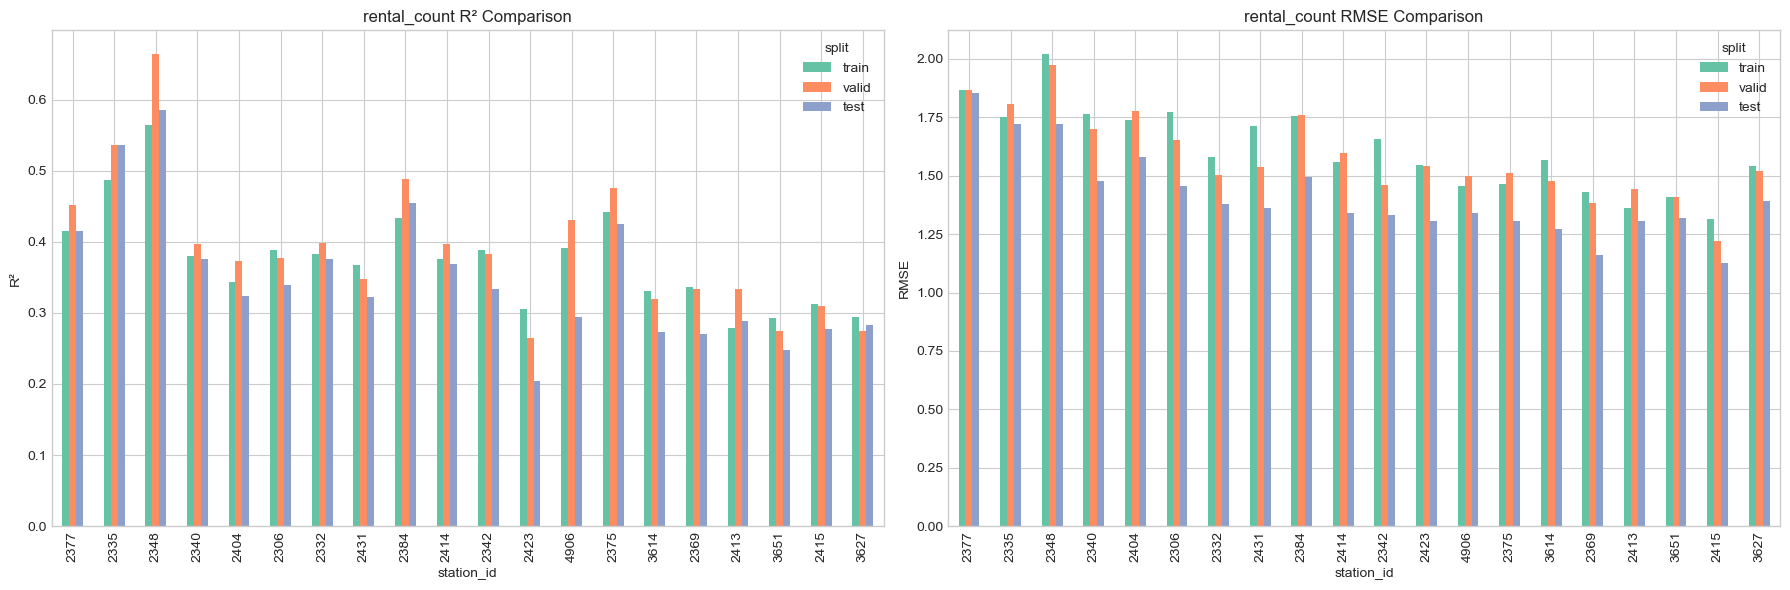

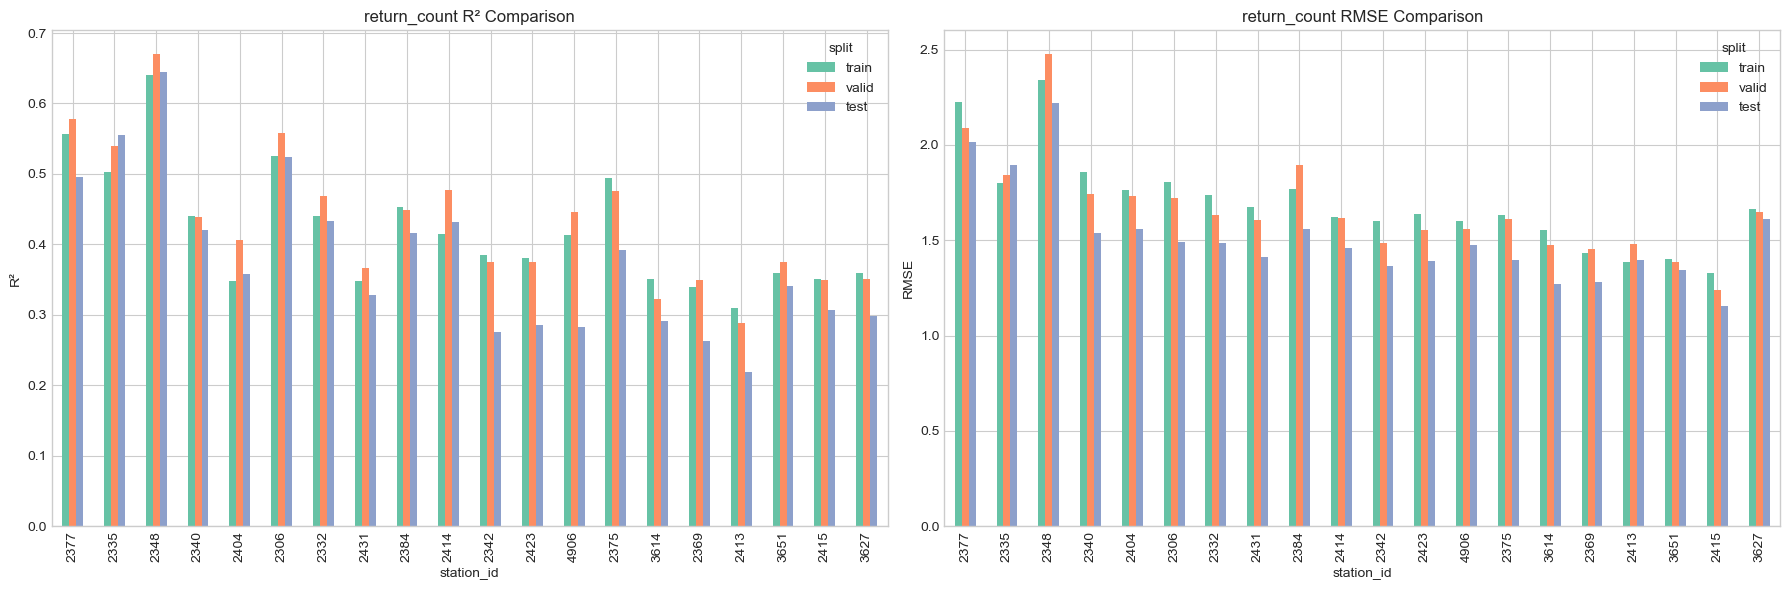

In [4]:
targets = ['rental_count', 'return_count']
for target in targets:
    view = metrics_df[metrics_df['target'] == target].copy()
    pivot_r2 = view.pivot(index='station_id', columns='split', values='r2').reindex(TOP20_STATIONS)
    pivot_rmse = view.pivot(index='station_id', columns='split', values='rmse').reindex(TOP20_STATIONS)
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    pivot_r2[['train', 'valid', 'test']].plot(kind='bar', ax=axes[0])
    axes[0].set_title(f'{target} R² Comparison')
    axes[0].set_xlabel('station_id')
    axes[0].set_ylabel('R²')
    pivot_rmse[['train', 'valid', 'test']].plot(kind='bar', ax=axes[1])
    axes[1].set_title(f'{target} RMSE Comparison')
    axes[1].set_xlabel('station_id')
    axes[1].set_ylabel('RMSE')
    plt.tight_layout()
    plt.show()


In [5]:
importance_frames = []
for station_id in TOP20_STATIONS:
    path = DATA_DIR / f'station_{station_id}_feature_importance.csv'
    df = pd.read_csv(path)
    df['station_id'] = station_id
    importance_frames.append(df)
importance_df = pd.concat(importance_frames, ignore_index=True)
importance_df.head()

,target,feature,alpha,coefficient,importance_abs,importance_ratio,station_id
0,rental_count,base_value,0.001,3.217644e-02,3.217644e-02,2.456025e-02,2377
1,rental_count,month_weight,0.001,1.541232e-01,1.541232e-01,1.176421e-01,2377
2,rental_count,year_weight,0.001,1.540205e-24,1.540205e-24,1.175637e-24,2377
3,rental_count,hour_weight,0.001,2.487863e-01,2.487863e-01,1.898984e-01,2377
4,rental_count,pattern_prior,0.001,-1.950282e-02,1.950282e-02,1.488649e-02,2377


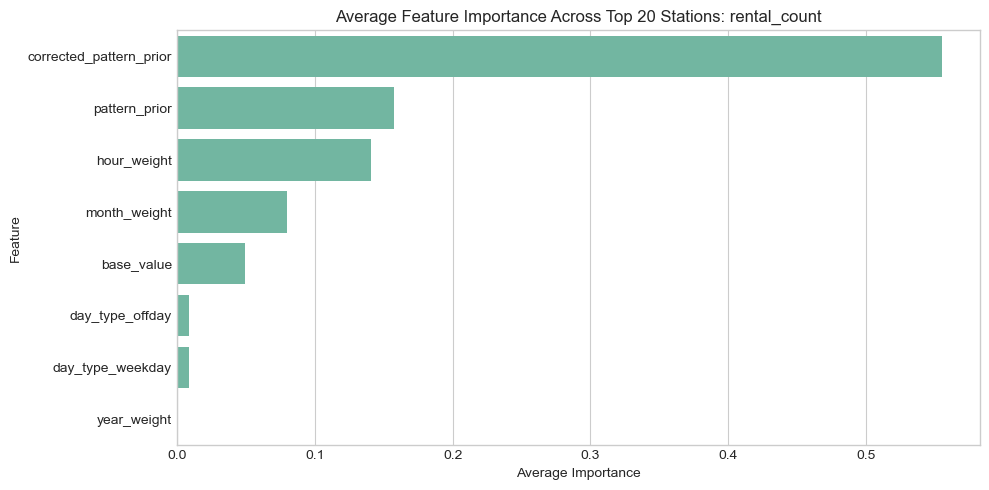

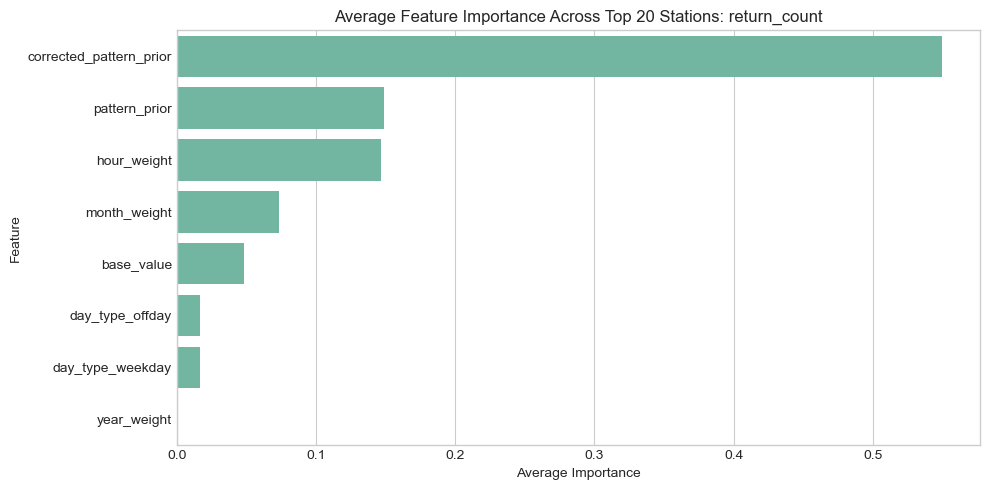

In [6]:
for target in ['rental_count', 'return_count']:
    target_df = importance_df[importance_df['target'] == target].copy()
    summary = (
        target_df.groupby('feature', as_index=False)['importance_ratio']
        .mean()
        .sort_values('importance_ratio', ascending=False)
    )
    plt.figure(figsize=(10, 5))
    sns.barplot(data=summary, x='importance_ratio', y='feature')
    plt.title(f'Average Feature Importance Across Top 20 Stations: {target}')
    plt.xlabel('Average Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()


In [7]:
comparison_frames = []
for station_id in TOP20_STATIONS:
    path = DATA_DIR / f'station_{station_id}_year_actual_vs_regression_vs_ml.csv'
    df = pd.read_csv(path)
    df['station_id'] = station_id
    comparison_frames.append(df)
comparison_df = pd.concat(comparison_frames, ignore_index=True)
comparison_df.head()

,target,granularity,year,key,series,value,station_id
0,rental_count,hour,2023,0,actual_value,0.726027,2377
1,rental_count,hour,2023,0,prediction,0.690836,2377
2,rental_count,hour,2023,1,actual_value,0.528767,2377
3,rental_count,hour,2023,1,prediction,0.534069,2377
4,rental_count,hour,2023,2,actual_value,0.336986,2377


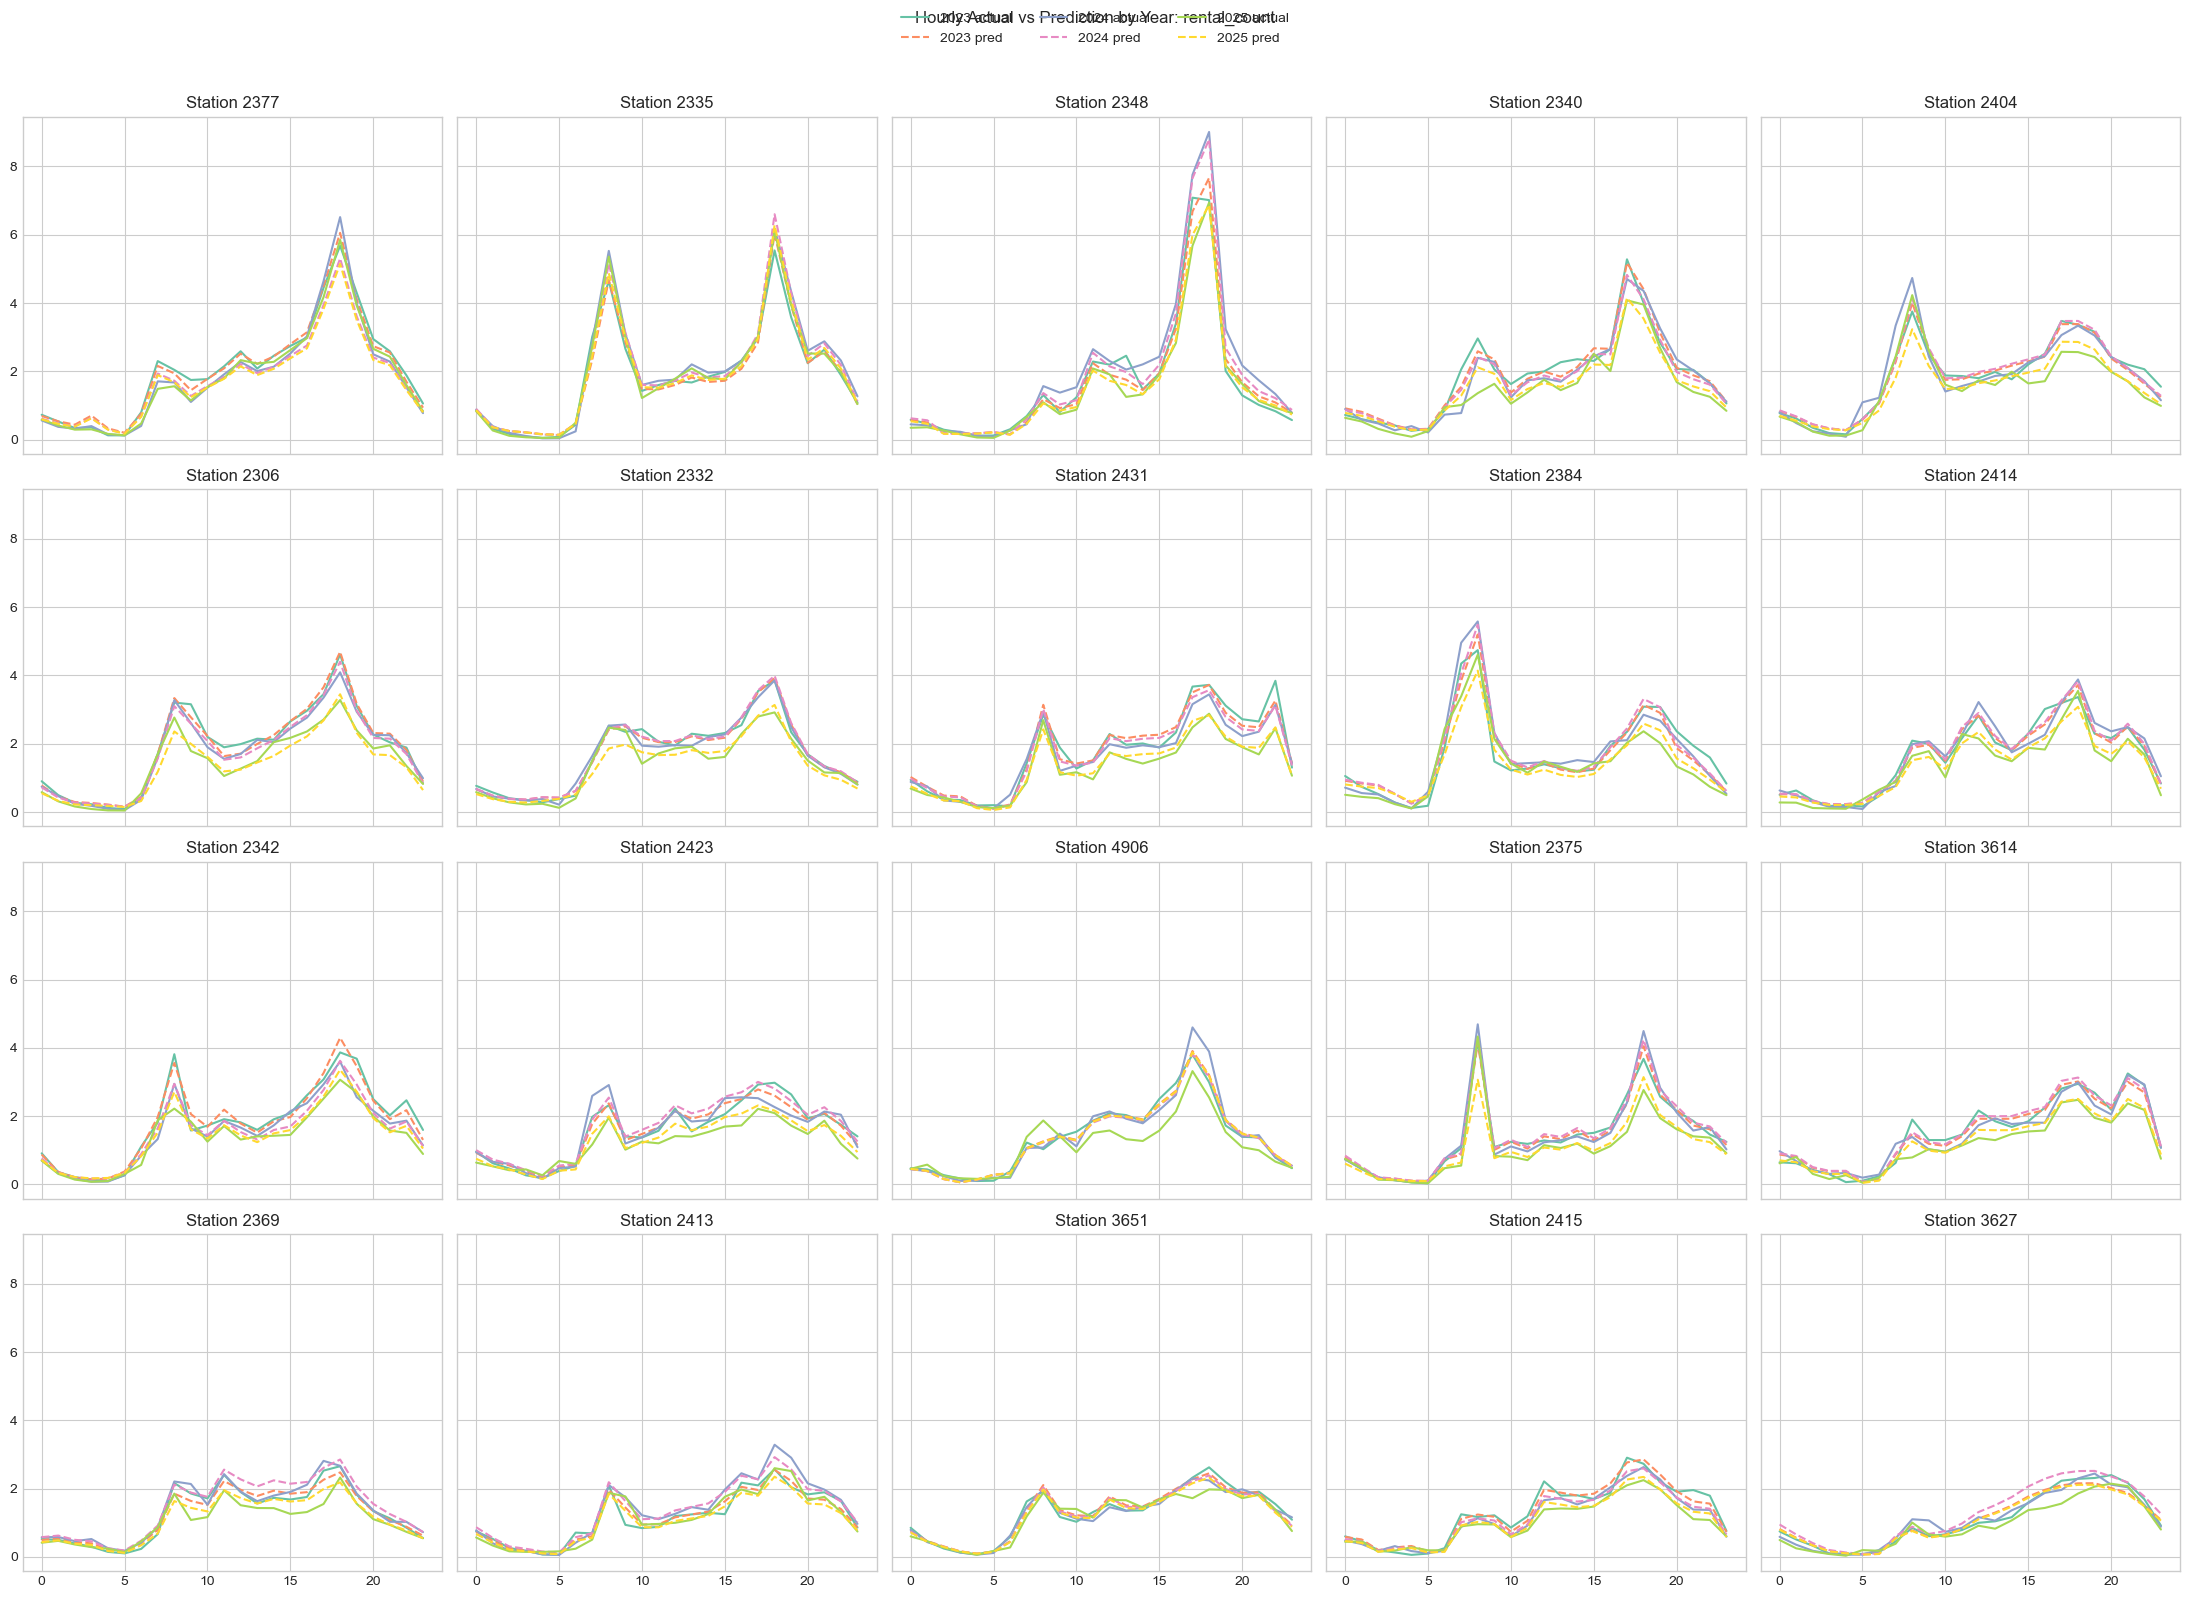

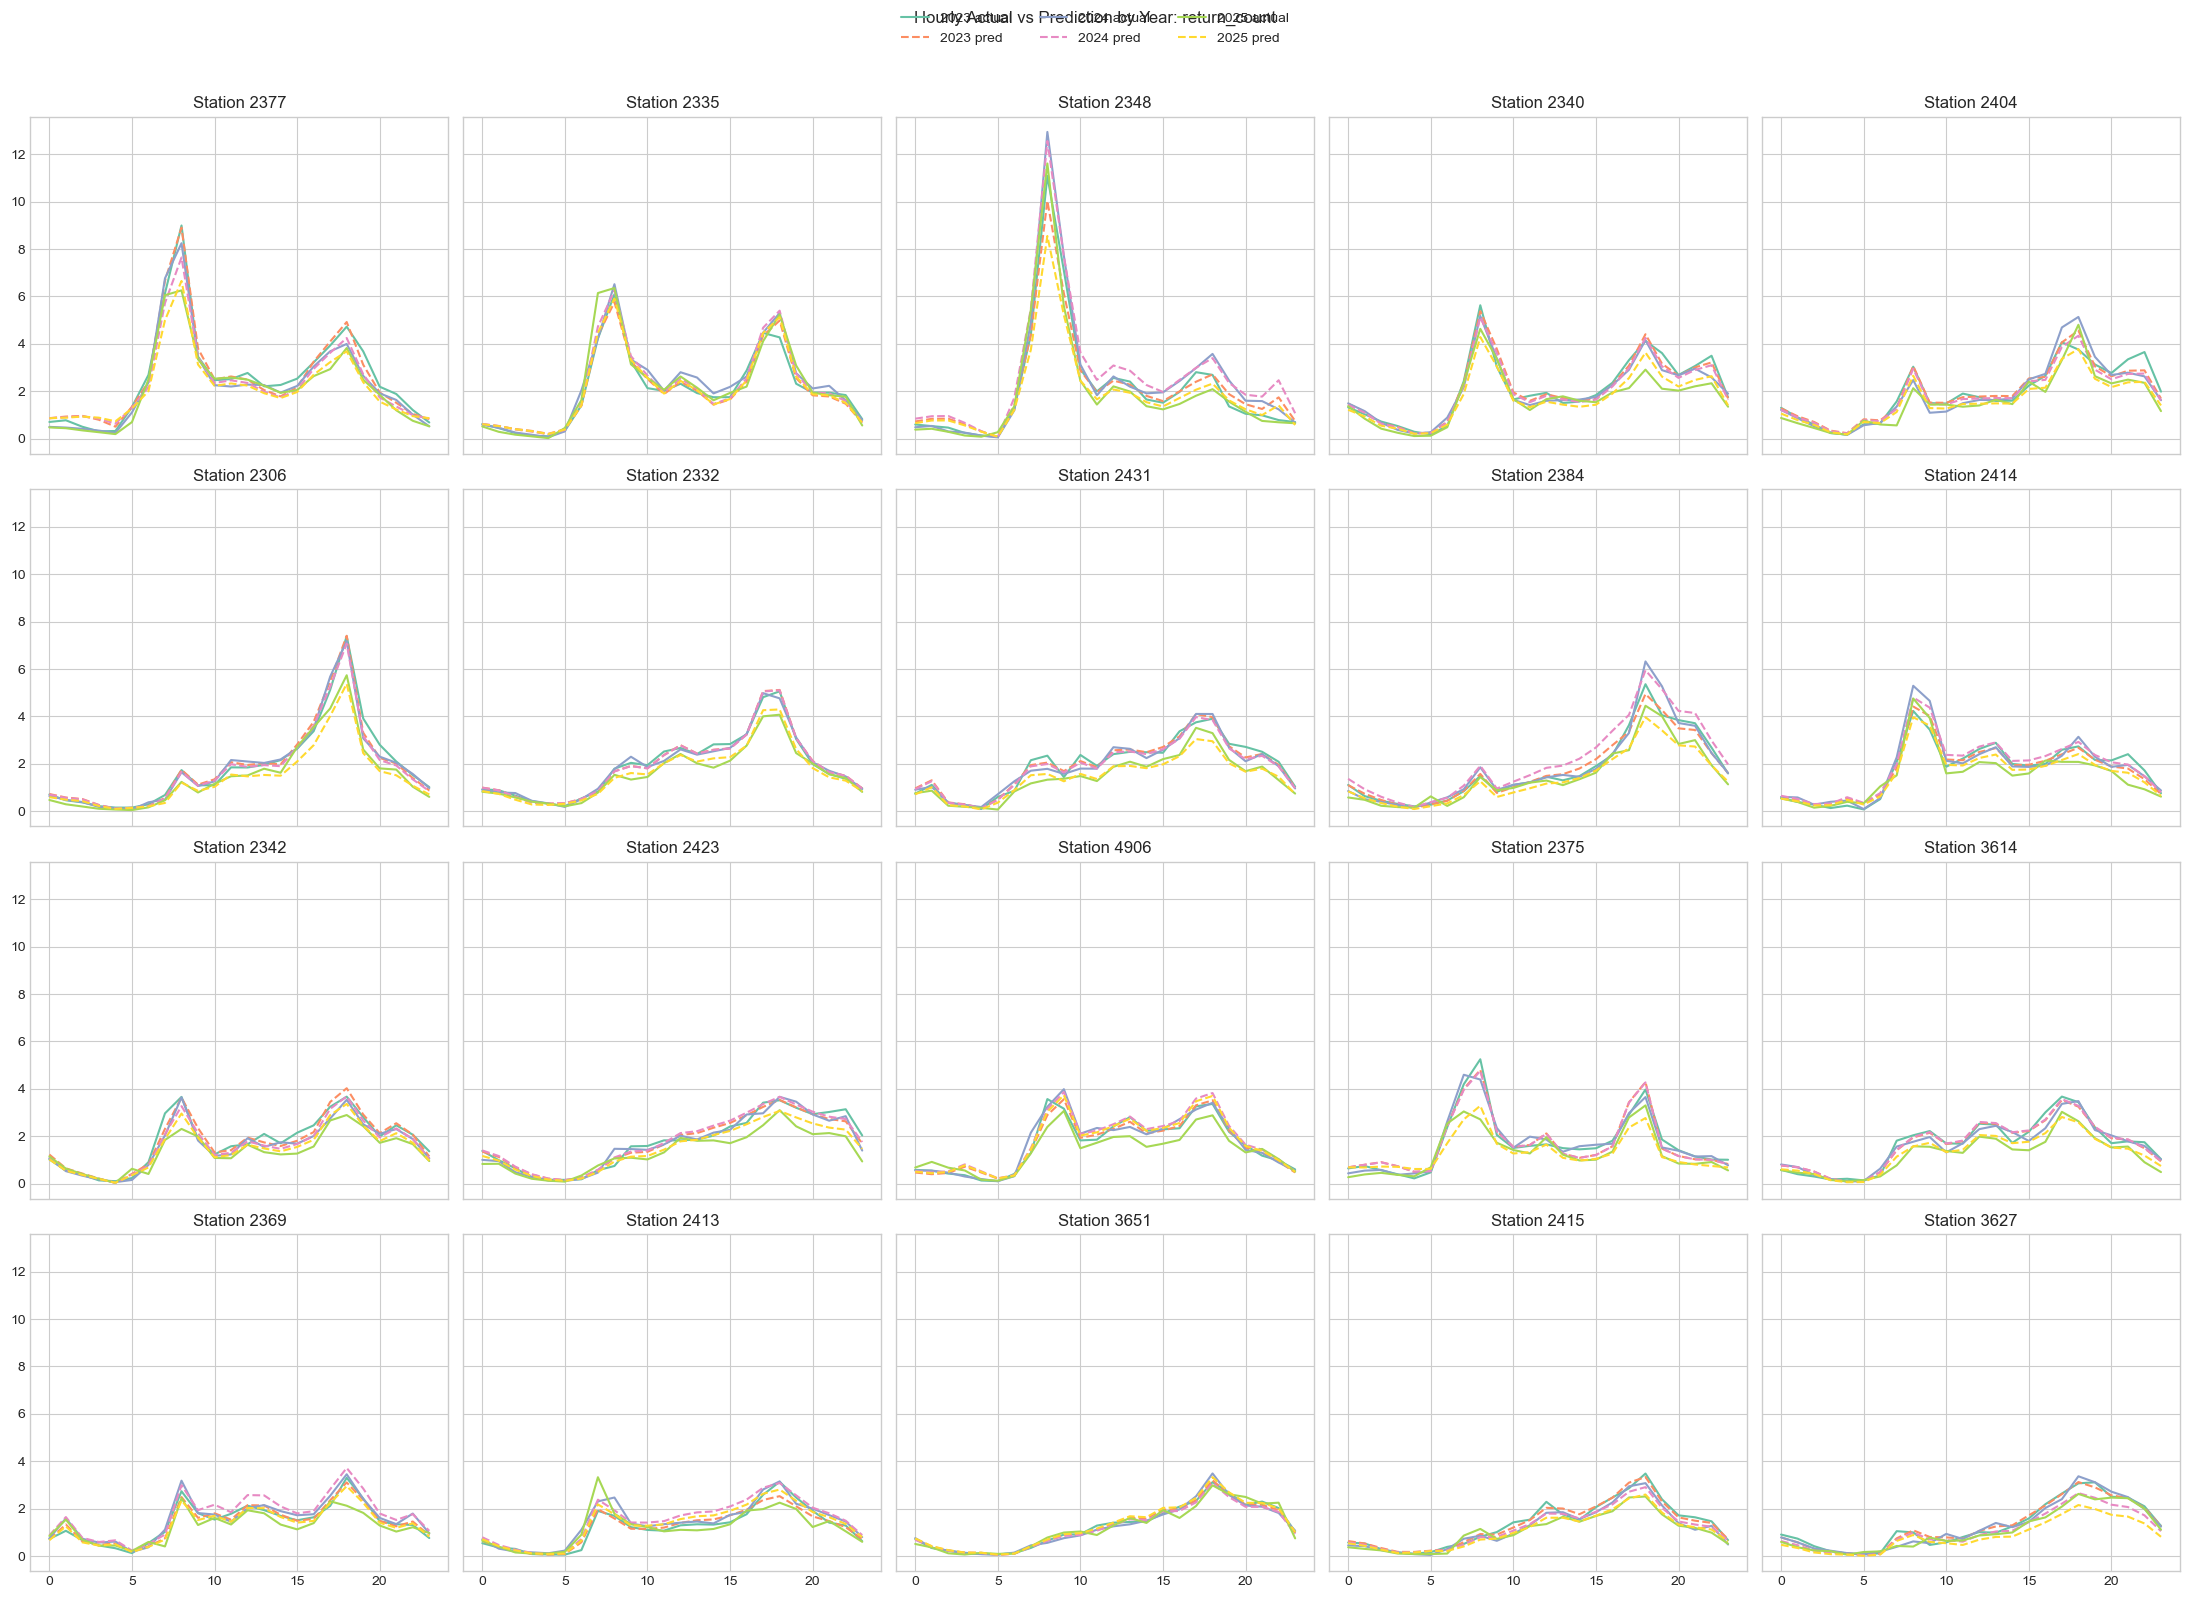

In [8]:
for target in ['rental_count', 'return_count']:
    target_df = comparison_df[(comparison_df['target'] == target) & (comparison_df['granularity'] == 'hour')].copy()
    yearly = (
        target_df.pivot_table(index=['station_id', 'year', 'key'], columns='series', values='value', aggfunc='mean')
        .reset_index()
    )
    fig, axes = plt.subplots(4, 5, figsize=(22, 16), sharex=True, sharey=True)
    axes = axes.flatten()
    for ax, station_id in zip(axes, TOP20_STATIONS):
        station_df = yearly[yearly['station_id'] == station_id]
        for year in sorted(station_df['year'].dropna().unique()):
            part = station_df[station_df['year'] == year]
            ax.plot(part['key'], part['actual_value'], label=f'{int(year)} actual')
            ax.plot(part['key'], part['prediction'], linestyle='--', label=f'{int(year)} pred')
        ax.set_title(f'Station {station_id}')
    for ax in axes[len(TOP20_STATIONS):]:
        ax.axis('off')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=3)
    fig.suptitle(f'Hourly Actual vs Prediction by Year: {target}', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


## Test R² Integrated Ranking

`rental_count`와 `return_count`의 test R²를 평균내어 station별 종합 점수를 계산하고, 높은 순서대로 시각화합니다.

In [9]:
test_r2_df = metrics_df[(metrics_df['split'] == 'test') & (metrics_df['target'].isin(['rental_count', 'return_count']))].copy()
ranking_df = (
    test_r2_df.pivot_table(index='station_id', columns='target', values='r2', aggfunc='mean')
    .reset_index()
)
ranking_df['combined_test_r2'] = ranking_df[['rental_count', 'return_count']].mean(axis=1)
ranking_df = ranking_df.sort_values('combined_test_r2', ascending=False).reset_index(drop=True)
ranking_df.index = ranking_df.index + 1
ranking_df.to_csv(DATA_DIR / 'top20_station_combined_test_r2_ranking.csv', index_label='rank', encoding='utf-8-sig')
ranking_df

target,station_id,rental_count,return_count,combined_test_r2
1,2348,0.584771,0.644110,0.614441
2,2335,0.536721,0.555205,0.545963
3,2377,0.415455,0.495743,0.455599
4,2384,0.455150,0.415902,0.435526
5,2306,0.339791,0.523467,0.431629
6,2375,0.425656,0.392174,0.408915
7,2332,0.376367,0.432790,0.404578
8,2414,0.368558,0.431418,0.399988
9,2340,0.375773,0.420577,0.398175
10,2404,0.323127,0.358095,0.340611


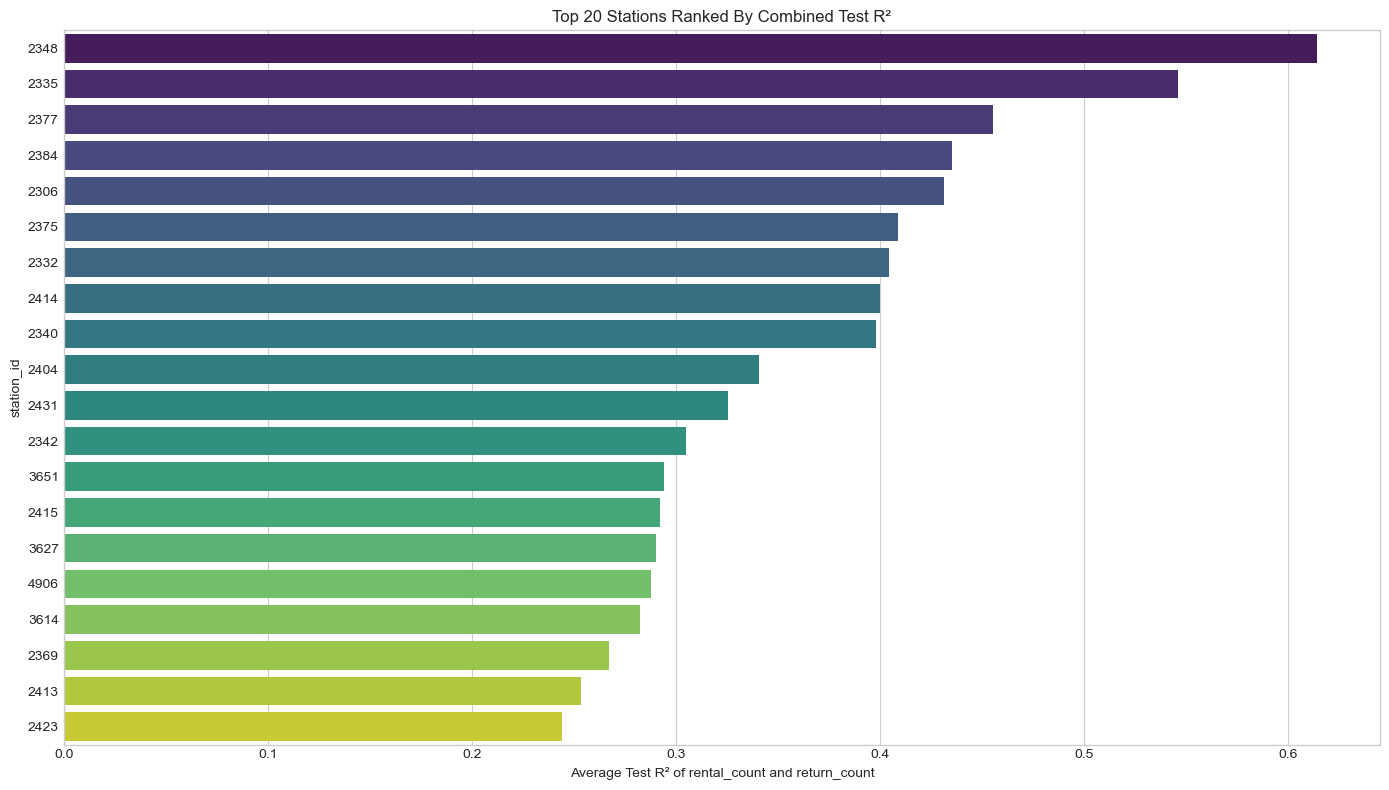

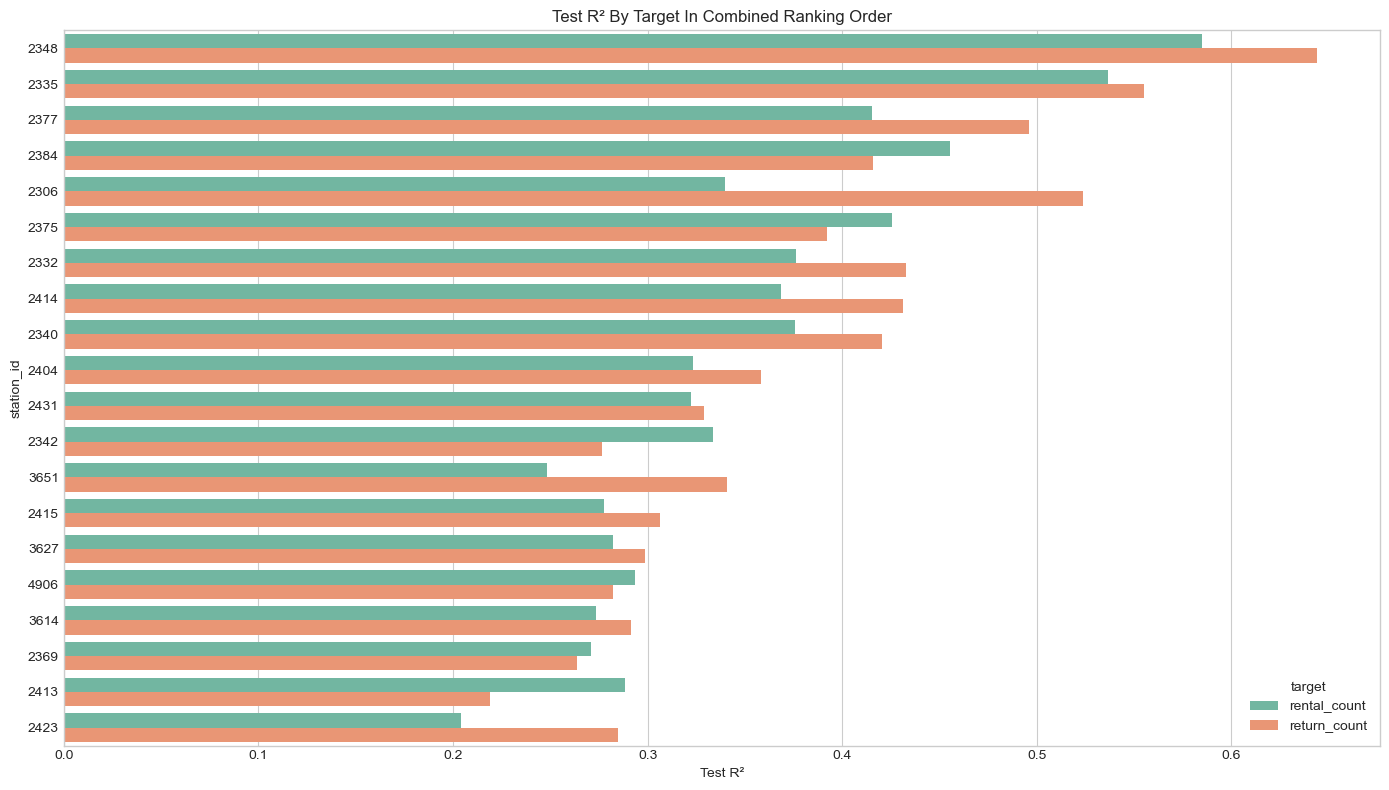

In [10]:
plot_df = ranking_df.reset_index().rename(columns={'index': 'rank'})
plt.figure(figsize=(14, 8))
sns.barplot(data=plot_df, x='combined_test_r2', y=plot_df['station_id'].astype(str), palette='viridis')
plt.title('Top 20 Stations Ranked By Combined Test R²')
plt.xlabel('Average Test R² of rental_count and return_count')
plt.ylabel('station_id')
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 8))
rank_melt_df = plot_df.melt(id_vars=['rank', 'station_id'], value_vars=['rental_count', 'return_count'], var_name='target', value_name='test_r2')
sns.barplot(data=rank_melt_df, x='test_r2', y=rank_melt_df['station_id'].astype(str), hue='target')
plt.title('Test R² By Target In Combined Ranking Order')
plt.xlabel('Test R²')
plt.ylabel('station_id')
plt.tight_layout()
plt.show()
